# Políticas — Altura de pallet

Hoy la carga máx. es **1800 mm** (~200 mm de buffer vs contenedor ~2000 mm).

Pregunta: **¿cuánto se puede aprovechar el pallet si aflojamos ese tope?**

Lecturas en el notebook:
- **§1–4 / cota:** Best mark16 (mismas cajas) vs piso analítico de rediseño g=3,0.
- **§5 (story):** **Reoptimizando bajo protocolo** a +50/+100/+150/+200 mm.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

_candidates = [Path.cwd(), Path.cwd().parent, Path("..").resolve()]
ROOT = next(p for p in _candidates if (p / "data" / "raw" / "operaciones_planta.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

from evaluate import (
    COSTO_PALLET,
    SUBMISSION_COLS,
    agregar_id_tipo_caja,
    calcular_cajas_por_pallet,
    evaluar_costos_solucion,
)
from mark16 import (
    _cands_eje,
    construir_productos,
    costo_actual_oficial,
    intervalos,
    score_publico,
)
from settings import (
    ECT,
    EPS,
    GRAVITY,
    PLANTAS,
    PRECIO_BASE_GROSOR,
)

GREEN = "#5CAC31"
GRAY = "#706F6F"
GREEN_DARK = "#3B7434"
LIGHT_GRAY = "#DADADA"
ACCENT = "#E45756"
BG = "#FFFFFF"

ALTO_HOY = 1800.0
ALTO_CONTENEDOR = 2000.0
DELTAS = [0, 1, 10, 20, 50, 54, 100, 150, 200]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": LIGHT_GRAY,
    "axes.labelcolor": GRAY,
    "axes.titlecolor": GREEN_DARK,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "text.color": GRAY,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
    "legend.frameon": False,
})


def style_ax(ax, title: str, subtitle: str | None = None):
    ax.set_facecolor(BG)
    ax.spines["bottom"].set_color(LIGHT_GRAY)
    ax.tick_params(length=0, colors=GRAY, labelsize=9)
    ax.yaxis.grid(True, color=LIGHT_GRAY, linewidth=0.8)
    ax.set_axisbelow(True)
    y_title = 1.16 if subtitle else 1.06
    ax.text(
        0.0, y_title, title,
        transform=ax.transAxes, fontsize=12, fontweight="bold",
        color=GREEN_DARK, va="bottom", ha="left", clip_on=False,
    )
    if subtitle:
        ax.text(
            0.0, 1.06, subtitle,
            transform=ax.transAxes, fontsize=9,
            color=GRAY, va="bottom", ha="left", clip_on=False,
        )


def annotate_bars(ax, bars, fmt, fontsize=9, color=GRAY):
    for bar in bars:
        h = bar.get_height()
        if not np.isfinite(h):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2, h,
            fmt(h), ha="center", va="bottom", color=color, fontsize=fontsize,
        )


def finish_fig(fig):
    fig.patch.set_facecolor(BG)
    fig.tight_layout(rect=[0, 0, 1, 0.88])
    fig.subplots_adjust(top=0.78)
    plt.show()


ops = pd.read_csv(ROOT / "data/raw/operaciones_planta.csv")
pt = pd.read_csv(ROOT / "data/processed/products_truth.csv")
best = pd.read_csv(ROOT / "outputs/tables/04_mark16_best_+10.11098.csv")[SUBMISSION_COLS].copy()
for df in (ops, pt, best):
    df["codigo_producto"] = df["codigo_producto"].astype(str).str.strip()

prod = construir_productos(pt, ops)
BASELINE = costo_actual_oficial(ops)

dims = prod[["largo", "ancho", "alto"]].to_numpy(float)
peso = prod["peso_neto_caja"].to_numpy(float)
volp = prod[[f"volumen_producto_planta_{p}" for p in PLANTAS]].to_numpy(float)
vol_total = float(prod["volumen_producto_total"].sum())
codes = prod["codigo_producto"].astype(str).tolist()

BEST_PATH = ROOT / "outputs/tables/04_mark16_best_+10.11098.csv"
TABLES = ROOT / "outputs" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)

print(f"Baseline: USD {BASELINE:,.0f}")
print(f"Altura hoy: {ALTO_HOY:.0f} mm | contenedor ≈ {ALTO_CONTENEDOR:.0f} mm | buffer ≈ {ALTO_CONTENEDOR - ALTO_HOY:.0f} mm")
print(f"SKUs: {len(prod)} | Best: {BEST_PATH.name}")


Baseline: USD 209,235,094
Altura hoy: 1800 mm | contenedor ≈ 2000 mm | buffer ≈ 200 mm
SKUs: 427 | Best: 04_mark16_best_+10.11098.csv


## 1. Holgura de altura hoy (Best, 1800 mm)

`slack = 1800 − capas × H_caja`. Es el aire libre arriba del pallet con las cajas actuales.


Slack: media 41.7 mm · mediana 6.0 mm · max 278.2 mm
Para ganar 1 capa: mediana 186 mm · mín 29 mm · p10 92 mm
SKUs con slack < 10 mm: 228 / 427


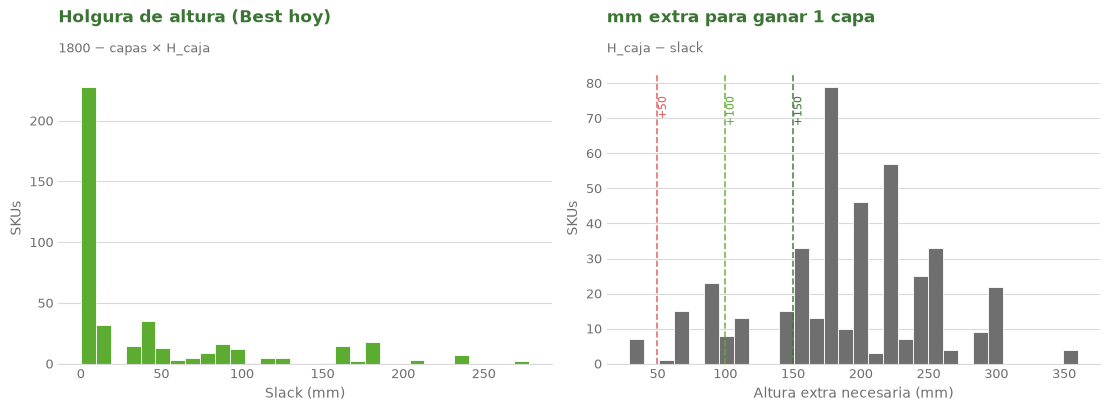

In [2]:
df0 = best.merge(ops[["codigo_producto", "volumen_producto_total"]], on="codigo_producto")
df0 = calcular_cajas_por_pallet(agregar_id_tipo_caja(df0), lim=(800.0, 1200.0, ALTO_HOY))

capas0 = np.floor(ALTO_HOY / df0["caja_exterior_alto"]).astype(int)
slack = ALTO_HOY - capas0 * df0["caja_exterior_alto"]
need = df0["caja_exterior_alto"] - slack  # mm extra para ganar 1 capa

df0 = df0.assign(capas=capas0, slack_mm=slack, need_mm=need)

print(
    f"Slack: media {slack.mean():.1f} mm · mediana {slack.median():.1f} mm · "
    f"max {slack.max():.1f} mm"
)
print(
    f"Para ganar 1 capa: mediana {need.median():.0f} mm · "
    f"mín {need.min():.0f} mm · p10 {need.quantile(0.10):.0f} mm"
)
print(f"SKUs con slack < 10 mm: {(slack < 10).sum()} / {len(slack)}")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))

ax = axes[0]
ax.hist(slack, bins=30, color=GREEN, edgecolor="white", linewidth=0.6)
style_ax(ax, "Holgura de altura (Best hoy)", "1800 − capas × H_caja")
ax.set_xlabel("Slack (mm)")
ax.set_ylabel("SKUs")

ax = axes[1]
ax.hist(need, bins=30, color=GRAY, edgecolor="white", linewidth=0.6)
style_ax(ax, "mm extra para ganar 1 capa", "H_caja − slack")
ax.set_xlabel("Altura extra necesaria (mm)")
ax.set_ylabel("SKUs")
for d, c in [(50, ACCENT), (100, GREEN), (150, GREEN_DARK)]:
    ax.axvline(d, color=c, ls="--", lw=1.2, alpha=0.85)
    ax.text(d, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] else 1, f"+{d}",
            color=c, fontsize=8, ha="left", va="top", rotation=90)

finish_fig(fig)


## 2. ¿Cuántos SKUs ganan una capa?

Con las **mismas cajas** de Best: solo cuenta si `altura_extra ≥ need_mm`.


,delta_mm,skus_ganan_capa,pct_skus,pct_volumen
0,0,0,0.0%,0.0%
1,1,0,0.0%,0.0%
2,10,0,0.0%,0.0%
3,20,0,0.0%,0.0%
4,50,7,1.6%,0.7%
5,54,8,1.9%,0.8%
6,100,46,10.8%,13.3%
7,150,82,19.2%,18.0%
8,200,257,60.2%,50.5%


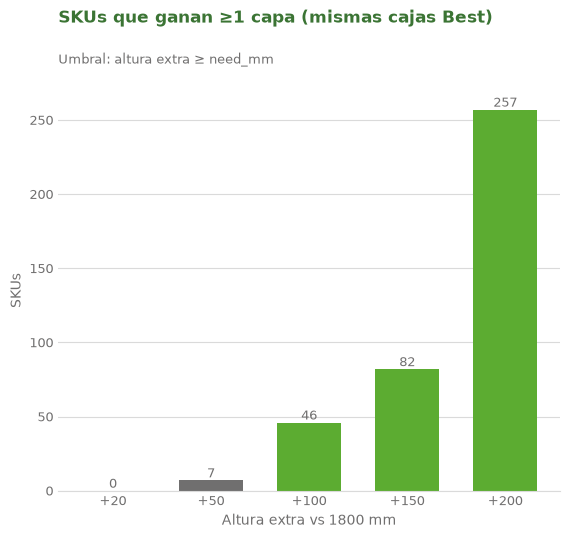

In [3]:
gain_rows = []
for d in DELTAS:
    n = int((need <= d).sum())
    vol = float(df0.loc[need <= d, "volumen_producto_total"].sum())
    gain_rows.append({
        "delta_mm": d,
        "skus_ganan_capa": n,
        "pct_skus": 100 * n / len(df0),
        "pct_volumen": 100 * vol / df0["volumen_producto_total"].sum(),
    })
tabla_capas = pd.DataFrame(gain_rows)
display(tabla_capas.style.format({
    "pct_skus": "{:.1f}%",
    "pct_volumen": "{:.1f}%",
}))

plot_capas = tabla_capas[tabla_capas["delta_mm"].isin([20, 50, 100, 150, 200])].copy()
deltas_plot = plot_capas["delta_mm"].tolist()

fig, ax = plt.subplots(figsize=(5.8, 5.8))
bars = ax.bar(
    [f"+{d}" for d in deltas_plot],
    plot_capas["skus_ganan_capa"],
    color=[GREEN if d >= 100 else GRAY for d in deltas_plot],
    width=0.65,
)
annotate_bars(ax, bars, lambda h: f"{h:.0f}")
style_ax(ax, "SKUs que ganan ≥1 capa (mismas cajas Best)", "Umbral: altura extra ≥ need_mm")
ax.set_ylabel("SKUs")
ax.set_xlabel("Altura extra vs 1800 mm")
finish_fig(fig)


## 3. Barrido de costo: Best (mismas cajas) vs Cota (rediseño g=3,0)

- **Best:** evaluador con `lim=(800, 1200, 1800+Δ)` sobre el catálogo actual.
- **Cota:** piso analítico rediseñando cajas con la nueva altura.


In [4]:
def cota_altura(alto_max: float, g: float = 3.0) -> dict:
    lim = (800.0, 1200.0, float(alto_max))
    lo, hi, vol_min = intervalos(prod, g)
    cpp_best = np.zeros(len(dims), dtype=int)
    for i in range(len(dims)):
        cands = [
            _cands_eje(float(lo[i, k]), float(hi[i, k]), lim[k], g) for k in range(3)
        ]
        best_cpp = 0
        for L in cands[0]:
            a = int(np.floor(lim[0] / (L + 2 * g)))
            for W in cands[1]:
                b = int(np.floor(lim[1] / (W + 2 * g)))
                carga_max = ECT[g] * 2 * (L + W + 4 * g) / 1000.0 / GRAVITY
                for H in cands[2]:
                    if L * W * H < vol_min[i] - 1e-6:
                        continue
                    c = int(np.floor(lim[2] / (H + 2 * g)))
                    if a < 1 or b < 1 or c < 1:
                        continue
                    if peso[i] * (c - 1) > carga_max + EPS:
                        continue
                    if a * b * c > best_cpp:
                        best_cpp = a * b * c
        if best_cpp == 0:
            raise RuntimeError(f"Sin caja factible para {codes[i]} con alto={alto_max}")
        cpp_best[i] = best_cpp

    flete = float((np.ceil(volp / cpp_best[:, None]) * COSTO_PALLET).sum())
    pack = PRECIO_BASE_GROSOR[g] * 0.70 * vol_total
    total = flete + pack
    return {"flete": flete, "pack": pack, "total": total, "score": score_publico(total, BASELINE)}


def eval_best(alto_max: float) -> dict:
    lim = (800.0, 1200.0, float(alto_max))
    ev = evaluar_costos_solucion(best, ops, lim=lim)
    det = ev["detalle_productos"]
    total = float(ev["resumen"]["costo_total_nuevo"].iloc[0])
    pack = float(ev["resumen"]["costo_packaging_nuevo"].iloc[0])
    flete = float(ev["resumen"]["costo_flete_nuevo"].iloc[0])
    capas = np.floor(alto_max / det["caja_exterior_alto"]).astype(int)
    cpp = (
        np.floor(800.0 / det["caja_exterior_largo"])
        * np.floor(1200.0 / det["caja_exterior_ancho"])
        * capas
    ).astype(int)
    vol_caja = (
        det["caja_exterior_largo"] * det["caja_exterior_ancho"] * det["caja_exterior_alto"]
    )
    util = cpp * vol_caja / (800.0 * 1200.0 * alto_max)
    util_w = float(np.average(util, weights=det["volumen_producto_total"]))
    return {
        "total": total,
        "pack": pack,
        "flete": flete,
        "score": score_publico(total, BASELINE),
        "util_pct": 100 * util_w,
        "capas_mean": float(capas.mean()),
    }


rows = []
for d in DELTAS:
    alto = ALTO_HOY + d
    b = eval_best(alto)
    c = cota_altura(alto)
    rows.append({
        "delta_mm": d,
        "alto_mm": alto,
        "best_total": b["total"],
        "best_score": b["score"],
        "best_util_pct": b["util_pct"],
        "best_capas_mean": b["capas_mean"],
        "cota_total": c["total"],
        "cota_score": c["score"],
        "ahorro_best": None,  # fill below
        "ahorro_cota": None,
    })

sweep = pd.DataFrame(rows)
ref_best = sweep.loc[sweep.delta_mm == 0, "best_total"].iloc[0]
ref_cota = sweep.loc[sweep.delta_mm == 0, "cota_total"].iloc[0]
sweep["ahorro_best"] = ref_best - sweep["best_total"]
sweep["ahorro_cota"] = ref_cota - sweep["cota_total"]

print("BARRIDO ALTURA DE PALLET")
display(sweep.style.format({
    "best_total": "{:,.0f}",
    "cota_total": "{:,.0f}",
    "best_score": "{:+.3f}",
    "cota_score": "{:+.3f}",
    "best_util_pct": "{:.1f}%",
    "best_capas_mean": "{:.2f}",
    "ahorro_best": "{:+,.0f}",
    "ahorro_cota": "{:+,.0f}",
}))


BARRIDO ALTURA DE PALLET


,delta_mm,alto_mm,best_total,best_score,best_util_pct,best_capas_mean,cota_total,cota_score,ahorro_best,ahorro_cota
0,0,1800.000000,"187,584,964",+10.347,93.9%,7.91,"187,321,433",+10.473,+0,+0
1,1,1801.000000,"187,584,964",+10.347,93.9%,7.91,"187,321,433",+10.473,+0,+0
2,10,1810.000000,"187,584,964",+10.347,93.4%,7.91,"186,735,383",+10.753,+0,"+586,050"
3,20,1820.000000,"187,584,964",+10.347,92.9%,7.91,"185,245,433",+11.465,+0,"+2,076,000"
4,50,1850.000000,"187,423,564",+10.424,91.5%,7.93,"182,951,633",+12.562,"+161,400","+4,369,800"
5,54,1854.000000,"187,413,814",+10.429,91.3%,7.93,"182,882,333",+12.595,"+171,150","+4,439,100"
6,100,1900.000000,"184,652,164",+11.749,90.7%,8.02,"179,720,783",+14.106,"+2,932,800","+7,600,650"
7,150,1950.000000,"183,739,864",+12.185,89.0%,8.10,"173,130,683",+17.255,"+3,845,100","+14,190,750"
8,200,2000.000000,"178,629,514",+14.627,90.1%,8.51,"169,828,583",+18.834,"+8,955,450","+17,492,850"


## 4. Costo total vs altura extra


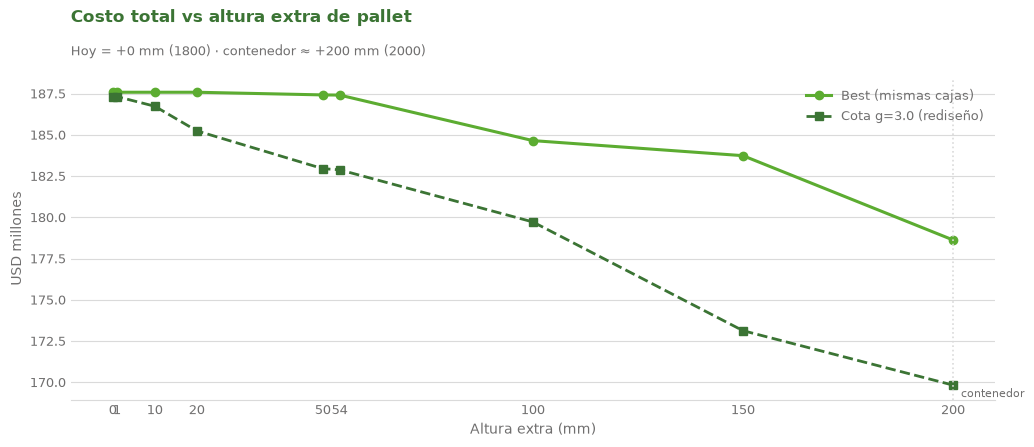

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = sweep["delta_mm"].to_numpy()
ax.plot(x, sweep["best_total"] / 1e6, "o-", color=GREEN, lw=2.2, label="Best (mismas cajas)")
ax.plot(x, sweep["cota_total"] / 1e6, "s--", color=GREEN_DARK, lw=2.0, label="Cota g=3.0 (rediseño)")
style_ax(
    ax,
    "Costo total vs altura extra de pallet",
    "Hoy = +0 mm (1800) · contenedor ≈ +200 mm (2000)",
)
ax.set_xlabel("Altura extra (mm)")
ax.set_ylabel("USD millones")
ax.set_xticks(DELTAS)
ax.legend(loc="upper right", fontsize=9)
ax.axvline(200, color=LIGHT_GRAY, ls=":", lw=1.2)
ax.text(200, ax.get_ylim()[0], "  contenedor", color=GRAY, fontsize=8, va="bottom")
finish_fig(fig)


## 5. Ahorro vs hoy (+0 mm) — Reoptimizando bajo protocolo

Una barra por altura (**+50 / +100 / +150 / +200 mm**): Mark17 re-optimizado under protocol
con `lim=(800,1200,1800+Δ)`, ahorro vs la solución bajo protocolo a 1800 mm.

Correr (si faltan resultados):
```bash
PYTHONPATH=src python scripts/run_mark17_altura_sweep.py
```


Ref Mark17 minbox @1800: USD 188,623,997 | score +9.851


,delta_mm,alto_mm,fixed_total,ahorro_fixed,reopt_total,ahorro_reopt
1,50,1850.000000,"188,623,997",+0,"184,527,286","+4,096,711"
2,100,1900.000000,"186,713,297","+1,910,700","181,547,622","+7,076,375"
3,150,1950.000000,"184,629,347","+3,994,650","174,250,745","+14,373,252"
4,200,2000.000000,"181,664,147","+6,959,850","171,504,626","+17,119,371"


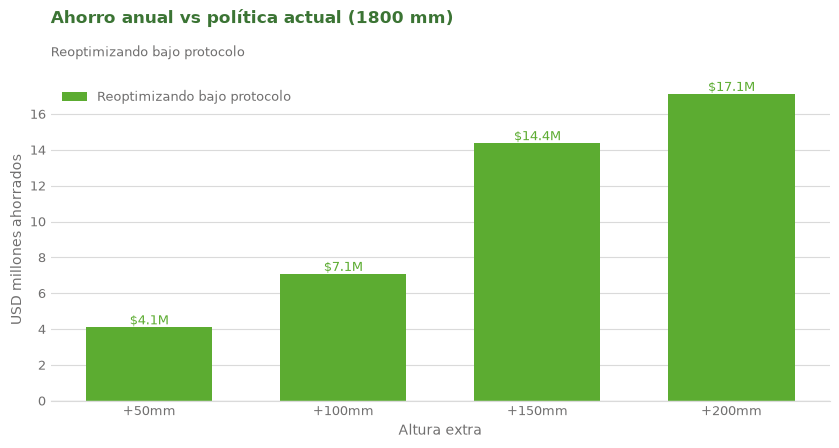

Guardado: outputs/tables/210_mark17_altura_ahorro.csv


In [8]:
MARK17_MINBOX_PATH = ROOT / "outputs/mark17/mark17_from_minbox.csv"
REOPT_SUMMARY_PATH = TABLES / "210_mark17_altura_reopt.csv"
REOPT_DIR = ROOT / "outputs/mark17/altura"
DELTAS_AHORRO = [50, 100, 150, 200]

m17 = pd.read_csv(MARK17_MINBOX_PATH)[SUBMISSION_COLS].copy()
m17["codigo_producto"] = m17["codigo_producto"].astype(str).str.strip()

ref_ev = evaluar_costos_solucion(m17, ops, lim=(800.0, 1200.0, ALTO_HOY))
ref_m17 = float(ref_ev["resumen"]["costo_total_nuevo"].iloc[0])

fixed_rows = []
for d in [0, *DELTAS_AHORRO]:
    alto = ALTO_HOY + d
    total = float(
        evaluar_costos_solucion(m17, ops, lim=(800.0, 1200.0, alto))["resumen"][
            "costo_total_nuevo"
        ].iloc[0]
    )
    fixed_rows.append(
        {
            "delta_mm": d,
            "alto_mm": alto,
            "fixed_total": total,
            "ahorro_fixed": ref_m17 - total,
            "fixed_score": score_publico(total, BASELINE),
        }
    )
plot = pd.DataFrame(fixed_rows)
plot = plot[plot["delta_mm"].isin(DELTAS_AHORRO)].copy()

# Reopt: preferir summary del script; si no, CSVs individuales.
reopt_map: dict[int, float] = {}
reopt_meta: dict[int, dict] = {}
if REOPT_SUMMARY_PATH.exists():
    sm = pd.read_csv(REOPT_SUMMARY_PATH)
    for r in sm.itertuples(index=False):
        if getattr(r, "ok", True) in (True, 1) and pd.notna(getattr(r, "reopt_total", np.nan)):
            reopt_map[int(r.delta_mm)] = float(r.reopt_total)
            reopt_meta[int(r.delta_mm)] = {
                "optimal": bool(getattr(r, "optimal_surrogate", False)),
                "n_tipos": int(getattr(r, "n_tipos", -1)),
                "elapsed_s": float(getattr(r, "elapsed_s", np.nan)),
            }
else:
    for d in DELTAS_AHORRO:
        alto = int(ALTO_HOY + d)
        pth = REOPT_DIR / f"mark17_minbox_h{alto}.csv"
        if not pth.exists():
            continue
        sol = pd.read_csv(pth)[SUBMISSION_COLS].copy()
        total = float(
            evaluar_costos_solucion(sol, ops, lim=(800.0, 1200.0, float(alto)))[
                "resumen"
            ]["costo_total_nuevo"].iloc[0]
        )
        reopt_map[d] = total

plot["reopt_total"] = plot["delta_mm"].map(reopt_map)
plot["ahorro_reopt"] = ref_m17 - plot["reopt_total"]
missing = [int(d) for d in DELTAS_AHORRO if d not in reopt_map]
if missing:
    print(
        f"Faltan reopts para Δ={missing}. Correr:\n"
        f"  PYTHONPATH=src python scripts/run_mark17_altura_sweep.py"
    )
else:
    print(
        f"Ref Mark17 minbox @1800: USD {ref_m17:,.0f} | "
        f"score {score_publico(ref_m17, BASELINE):+.3f}"
    )
    display(
        plot[
            [
                "delta_mm",
                "alto_mm",
                "fixed_total",
                "ahorro_fixed",
                "reopt_total",
                "ahorro_reopt",
            ]
        ].style.format(
            {
                "fixed_total": "{:,.0f}",
                "reopt_total": "{:,.0f}",
                "ahorro_fixed": "{:+,.0f}",
                "ahorro_reopt": "{:+,.0f}",
            }
        )
    )

labels = [f"+{int(d)}mm" for d in plot["delta_mm"]]
xpos = np.arange(len(plot))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    xpos,
    plot["ahorro_reopt"] / 1e6,
    width=0.65,
    color=GREEN,
    label="Reoptimizando bajo protocolo",
)
annotate_bars(ax, bars, lambda h: f"${h:.1f}M", fontsize=9, color=GREEN)

style_ax(
    ax,
    "Ahorro anual vs política actual (1800 mm)",
    "Reoptimizando bajo protocolo",
)
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_xlabel("Altura extra")
ax.set_ylabel("USD millones ahorrados")
ax.axhline(0, color=LIGHT_GRAY, lw=1)
ax.legend(loc="upper left", fontsize=9)
finish_fig(fig)

out_m17 = TABLES / "210_mark17_altura_ahorro.csv"
plot.to_csv(out_m17, index=False)
print(f"Guardado: {out_m17.relative_to(ROOT)}")

## 6. Utilización volumétrica del pallet (Best, mismas cajas)

Ojo: al subir la altura **sin** rediseñar, el % de llenado del *nuevo* volumen puede bajar hasta que se gane una capa.


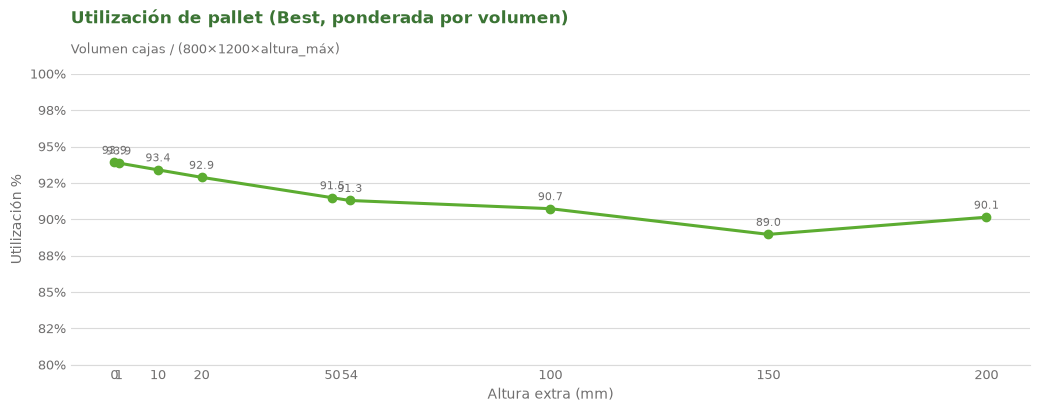

Guardado: outputs/tables/210_altura_pallet_sweep.csv


In [7]:
fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.plot(sweep["delta_mm"], sweep["best_util_pct"], "o-", color=GREEN, lw=2.2)
style_ax(
    ax,
    "Utilización de pallet (Best, ponderada por volumen)",
    "Volumen cajas / (800×1200×altura_máx)",
)
ax.set_xlabel("Altura extra (mm)")
ax.set_ylabel("Utilización %")
ax.set_xticks(DELTAS)
ax.set_ylim(80, 100)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for _, r in sweep.iterrows():
    ax.text(
        r["delta_mm"], r["best_util_pct"] + 0.4,
        f"{r['best_util_pct']:.1f}", ha="center", va="bottom", fontsize=8, color=GRAY,
    )
finish_fig(fig)

out = TABLES / "210_altura_pallet_sweep.csv"
sweep.to_csv(out, index=False)
print("Guardado:", out.relative_to(ROOT))


## Lectura

Gráfico §5 — ahorro anual vs Mark17 minbox @1800 (`210_mark17_altura_reopt.csv`, surrogate óptimo en todos los Δ):

| Extra | Fijo (mismas cajas) | Reopt Mark17 |
|------:|--------------------:|-------------:|
| **+50 mm** | **USD 0** | **~USD 4,1 M** |
| **+100 mm** | **~USD 1,9 M** | **~USD 7,1 M** |
| **+150 mm** | **~USD 4,0 M** | **~USD 14,4 M** |
| **+200 mm** | **~USD 7,0 M** | **~USD 17,1 M** |

1. Con el catálogo minbox fijo, a **+50 mm** nadie gana capa → ahorro 0; el upside está todo en **rediseñar**.
2. El gap fijo→reopt crece con la altura: a +200 mm son ~USD 10 M extra por reopt vs solo apilar.
3. El buffer de 200 mm es una palanca de política del orden de **USD 17 M/año** si se reoptimiza el catálogo.
